In [36]:
import pandas as pd 

df = pd.read_csv ("../data/esol.csv")
df.head()

,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.30,Cc1occc1C(=O)Nc2ccccc2
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O)
3,Picene,-6.618,2,278.354,0,5,0,0.00,-7.87,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
4,Thiophene,-2.232,2,84.143,0,1,0,0.00,-1.33,c1ccsc1


In [37]:
df.shape


(1128, 10)

In [38]:
df.columns

Index(['Compound ID', 'ESOL predicted log solubility in mols per litre',
       'Minimum Degree', 'Molecular Weight', 'Number of H-Bond Donors',
       'Number of Rings', 'Number of Rotatable Bonds', 'Polar Surface Area',
       'measured log solubility in mols per litre', 'smiles'],
      dtype='str')

In [39]:
from rdkit import Chem

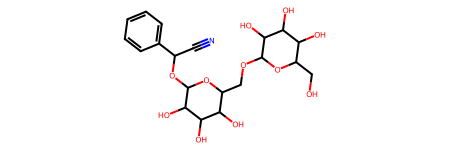

In [40]:
smiles = df["smiles"][0]
mol = Chem.MolFromSmiles(smiles)
mol

In [41]:
print(type(mol))


<class 'rdkit.Chem.rdchem.Mol'>


In [42]:
df["mol"] = df["smiles"].apply(Chem.MolFromSmiles)

In [43]:
df[["smiles", "mol"]].head()

,smiles,mol
0,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,<rdkit.Chem.rdchem.Mol object at 0x739476329850>
1,Cc1occc1C(=O)Nc2ccccc2,<rdkit.Chem.rdchem.Mol object at 0x7394763294d0>
2,CC(C)=CCCC(C)=CC(=O),<rdkit.Chem.rdchem.Mol object at 0x739476329460>
3,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,<rdkit.Chem.rdchem.Mol object at 0x7394763293f0>
4,c1ccsc1,<rdkit.Chem.rdchem.Mol object at 0x739476329380>


In [44]:
df["mol"].isnull().sum()

np.int64(0)

In [45]:
from rdkit.Chem import rdFingerprintGenerator

In [46]:
morgan_generator = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=2048
)

fingerprint = morgan_generator.GetFingerprint(mol)

fingerprint

In [47]:
len(fingerprint)

2048

In [48]:
list(fingerprint)[:20]

[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

In [49]:
from rdkit.Chem import Descriptors, rdMolDescriptors
import numpy as np

def mol_to_features(mol):
    # Morgan fingerprint
    fingerprint = morgan_generator.GetFingerprint(mol)
    fingerprint_array = np.array(fingerprint)

    # RDKit descriptors
    descriptors = np.array([
        Descriptors.MolWt(mol),                    # Molecular Weight
        Descriptors.MolLogP(mol),                  # LogP
        rdMolDescriptors.CalcTPSA(mol),            # TPSA
        rdMolDescriptors.CalcNumHBD(mol),          # H-bond donors
        rdMolDescriptors.CalcNumHBA(mol),          # H-bond acceptors
        rdMolDescriptors.CalcNumRings(mol),        # Rings
        rdMolDescriptors.CalcNumRotatableBonds(mol)
    ])

    # Combine fingerprint + descriptors
    return np.concatenate([fingerprint_array, descriptors])

X = np.array([mol_to_features(mol) for mol in df["mol"]])

y = df["measured log solubility in mols per litre"].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1128, 2055)
y shape: (1128,)


In [50]:
print(X[1][:20])
print(y[1])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
-3.3


In [51]:
# tarining  of data for   model

from sklearn.model_selection import train_test_split

X_train ,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (902, 2055)
X_test: (226, 2055)
y_train: (902,)
y_test: (226,)


In [52]:
# train first model  Random Forest :

In [53]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest training complete")

Random Forest training complete


In [54]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_predictions = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, rf_predictions)
rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

Random Forest Results
MAE: 0.5451008002528447
RMSE: 0.7878137685693654
R²: 0.8686955073702625


In [57]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),
    "XGBoost": XGBRegressor(
        random_state=42
    ),
    "LightGBM": LGBMRegressor(
        random_state=42
    ),
    "Neural Network": MLPRegressor(
        hidden_layer_sizes=(128, 64),
        max_iter=500,
        random_state=42
    )
}

results = []

for name, model in models.items():

    # Train model
    model.fit(X_train, y_train)

    # Predict
    predictions = model.predict(X_test)

    # Metrics
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results)

results_df.sort_values(by="RMSE")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001815 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1007
[LightGBM] [Info] Number of data points in the train set: 902, number of used features: 179
[LightGBM] [Info] Start training from score -3.044929


/workspaces/Molecular-Prediction/backend/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,Model,MAE,RMSE,R2
5,LightGBM,0.497625,0.709806,0.893411
4,XGBoost,0.520779,0.745691,0.882361
3,Gradient Boosting,0.565720,0.777971,0.871956
2,Random Forest,0.545101,0.787814,0.868696
6,Neural Network,0.567103,0.800968,0.864274
1,Ridge Regression,0.618744,0.857491,0.844442
0,Linear Regression,1.255196,1.874314,0.256780


In [60]:
import joblib

best_model = models["LightGBM"]

joblib.dump(best_model, "../models/best_model.pkl")

print("LightGBM model saved")

LightGBM model saved


In [62]:
loaded_model = joblib.load("../models/best_model.pkl")

prediction = loaded_model.predict(X_test[:1])

print("Prediction:", prediction)
print("Actual:", y_test[:1])

Prediction: [-2.54974783]
Actual: [-2.54]


/workspaces/Molecular-Prediction/backend/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [63]:
df[df["smiles"] == "CCO"]

,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles,mol
983,Ethanol,0.02,1,46.069,1,0,0,20.23,1.1,CCO,<rdkit.Chem.rdchem.Mol object at 0x739476323bc0>


In [64]:
df[df["smiles"] == "c1ccccc1"]

,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles,mol
835,Benzene,-2.418,2,78.114,0,1,0,0.0,-1.64,c1ccccc1,<rdkit.Chem.rdchem.Mol object at 0x739476327d10>
